# Career Growth Intelligence - Visual Analytics

This notebook contains production-ready visualizations for the Career Growth Intelligence module. Each chart is presented with a short business objective followed by the corresponding visualization code.


In [6]:
import platform
import numpy as np
import pandas as pd
import matplotlib
from matplotlib.ticker import StrMethodFormatter
import matplotlib.pyplot as plt
import seaborn as sns

# Optimize pandas display configurations for comprehensive data inspection.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

# Log framework metadata and verification metrics.
print("Environment Information")
print("-" * 22)
print(f"Python Version     : {platform.python_version()}")
print(f"Pandas Version     : {pd.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Matplotlib Version : {matplotlib.__version__}")
print(f"Seaborn Version    : {sns.__version__}")

Environment Information
----------------------
Python Version     : 3.14.6
Pandas Version     : 3.0.3
NumPy Version      : 2.4.6
Matplotlib Version : 3.11.0
Seaborn Version    : 0.13.2


In [7]:
# Load target dataset

DATA_PATH = "../../data/processed/cleaned_ai_jobs.csv"
df = pd.read_csv(DATA_PATH)
print("\nDataset Loaded Successfully")

# Execute descriptive matrix shape verification.

print("\nDataset Shape")
print("-" * 16)

total_rows, total_columns = df.shape

print(f"Rows    : {total_rows:,}")
print(f"Columns : {total_columns}")
print("-" * 16)

# Display a quick preview of the dataset schema.

display(df.head())


Dataset Loaded Successfully

Dataset Shape
----------------
Rows    : 90,000
Columns : 35
----------------


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,Small,7,2020,Remote,44.7,3.67,10,52.77,0.404,91,3.30,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,Small,3,2021,Onsite,48.9,4.26,27,53.11,0.387,71,4.39,62.14,13,75.80,28.4,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,Phd,Healthcare,Large,3,2020,Remote,46.8,4.78,10,76.40,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
3,4,India,AI Software Engineer,Computer Vision,Senior,6,43268,7975,Diploma,Tech,Large,2,2026,Onsite,52.2,4.34,23,59.34,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,Medium,2,2021,Hybrid,46.7,4.49,17,72.30,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72


## Chart 1: Career Growth Score Distribution

**Business Objective:** Visualize **career growth score distribution** to support career growth analysis and decision-making.

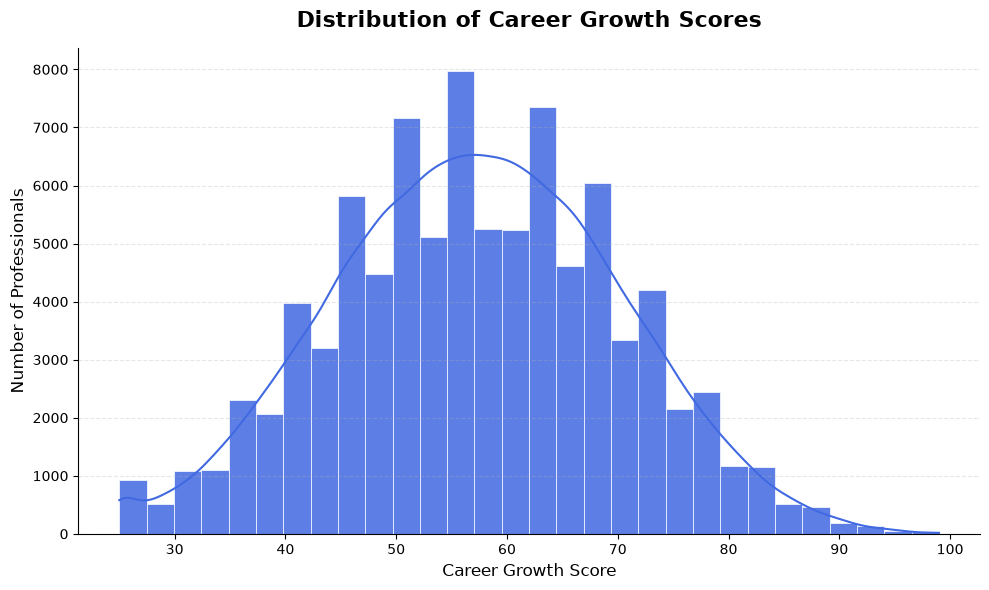

In [8]:
# Chart 1: Career Growth Score Distribution

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="career_growth_score",
    bins=30,
    kde=True,
    color="royalblue",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Career Growth Scores", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Career Growth Score", fontsize=12)
ax.set_ylabel("Number of Professionals", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 2: Promotion Speed Distribution

**Business Objective:** Visualize **promotion speed distribution** to support career growth analysis and decision-making.

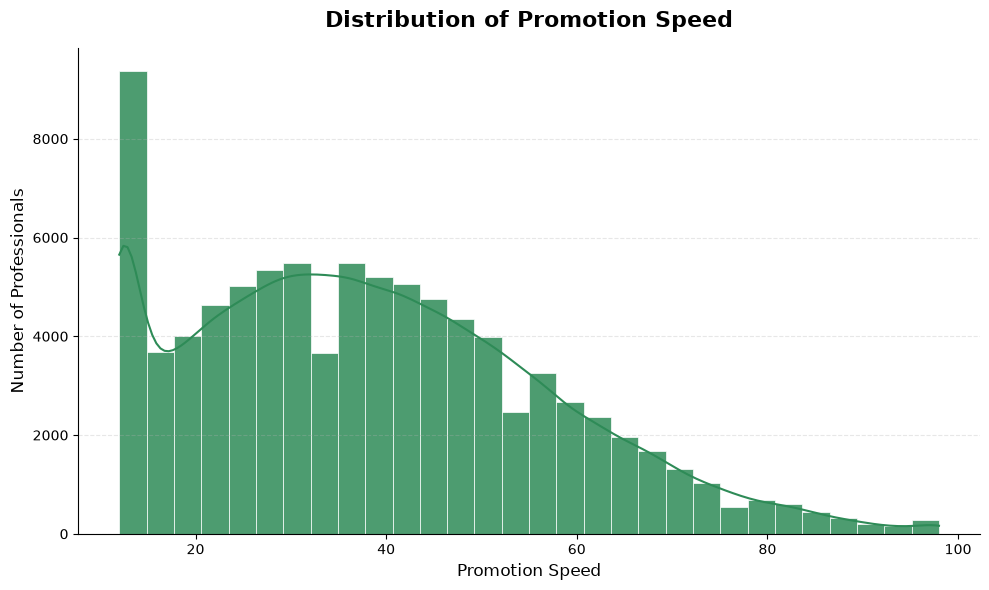

In [9]:
# Chart 2: Promotion Speed Distribution

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="promotion_speed",
    bins=30,
    kde=True,
    color="seagreen",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Promotion Speed", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Promotion Speed", fontsize=12)
ax.set_ylabel("Number of Professionals", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 3: Career Growth by Experience Level

**Business Objective:** Visualize **career growth by experience level** to support career growth analysis and decision-making.

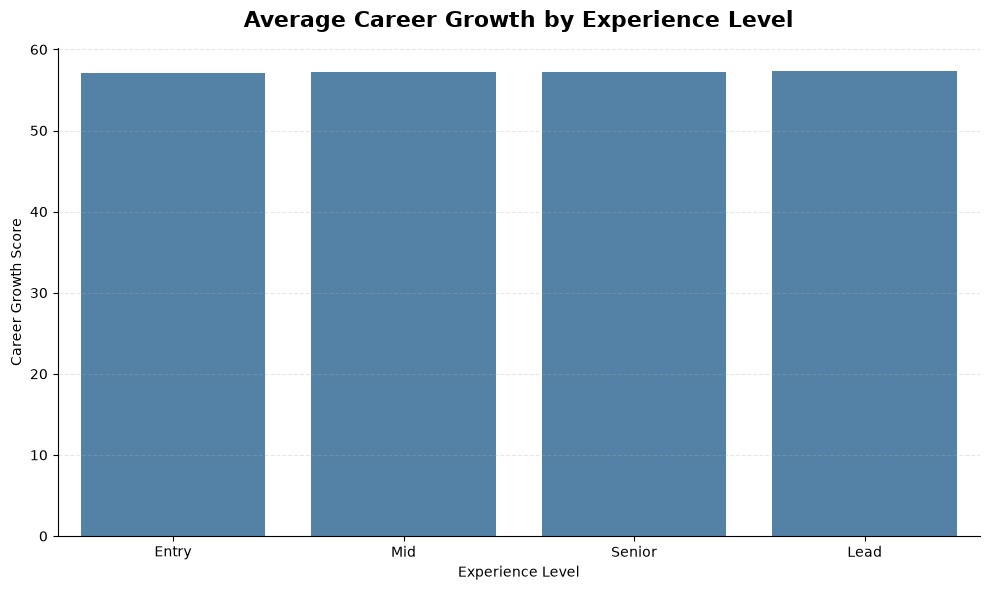

In [14]:
# Chart 3: Career Growth by Experience Level

career_growth_exp = (
    df.groupby("experience_level", observed=False)["career_growth_score"]
    .mean()
    .reindex(experience_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=career_growth_exp,
    x="experience_level",
    y="career_growth_score",
    color="steelblue",
    ax=ax
)


ax.set_title(
    "Average Career Growth by Experience Level",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Experience Level")
ax.set_ylabel("Career Growth Score")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

## Chart 4: Top 10 Countries by Career Growth

**Business Objective:** Visualize **top 10 countries by career growth** to support career growth analysis and decision-making.

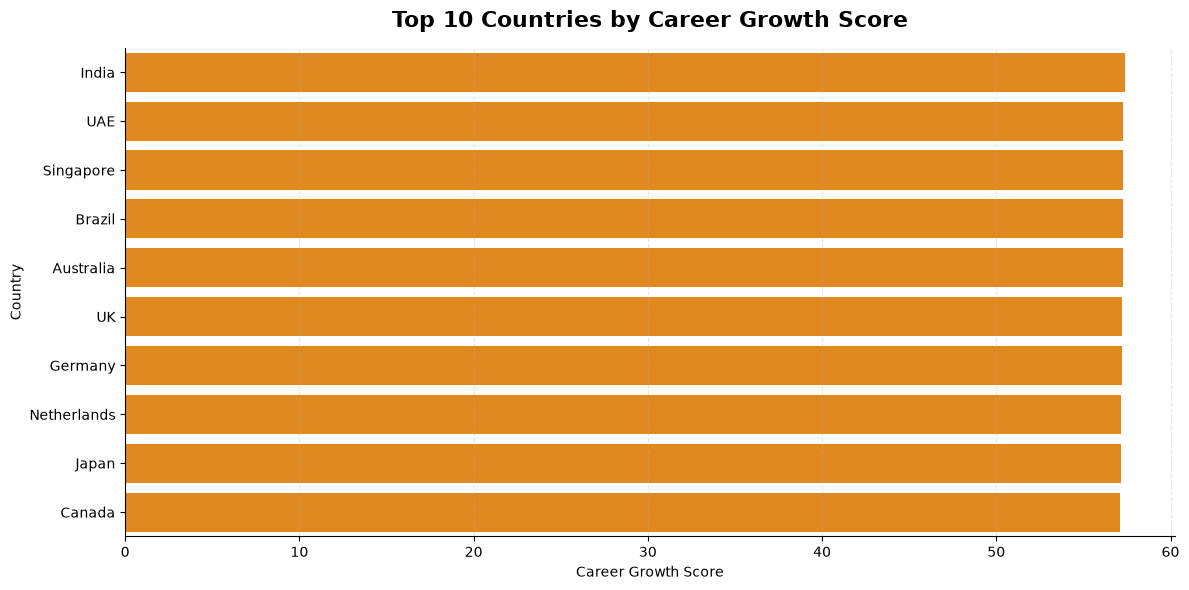

In [16]:
# Chart 4: Top 10 Countries by Career Growth

career_country = (
    df.groupby("country")["career_growth_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=career_country,
    x="career_growth_score",
    y="country",
    color="darkorange",
    ax=ax
)

ax.set_title(
    "Top 10 Countries by Career Growth Score",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Career Growth Score")
ax.set_ylabel("Country")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

## Chart 5: Top 10 Job Roles by Career Growth

**Business Objective:** Visualize **top 10 job roles by career growth** to support career growth analysis and decision-making.

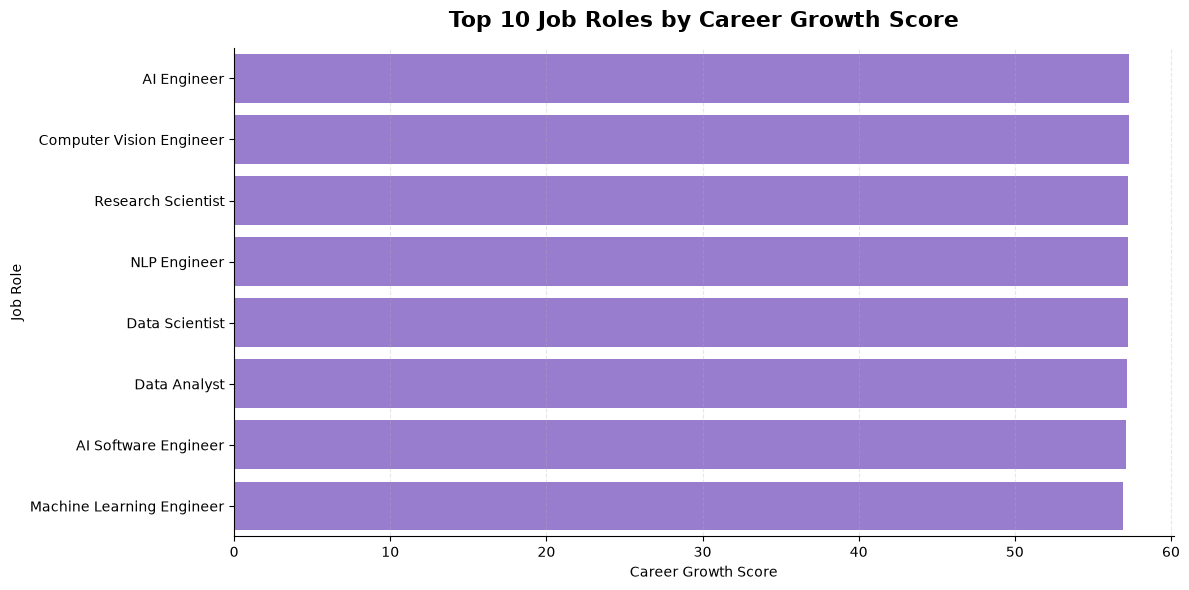

In [17]:
# Chart 5: Top 10 Job Roles by Career Growth

career_role = (
    df.groupby("job_role")["career_growth_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=career_role,
    x="career_growth_score",
    y="job_role",
    color="mediumpurple",
    ax=ax
)


ax.set_title(
    "Top 10 Job Roles by Career Growth Score",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Career Growth Score")
ax.set_ylabel("Job Role")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

## Chart 6: Career Growth by AI Specialization

**Business Objective:** Visualize **career growth by ai specialization** to support career growth analysis and decision-making.

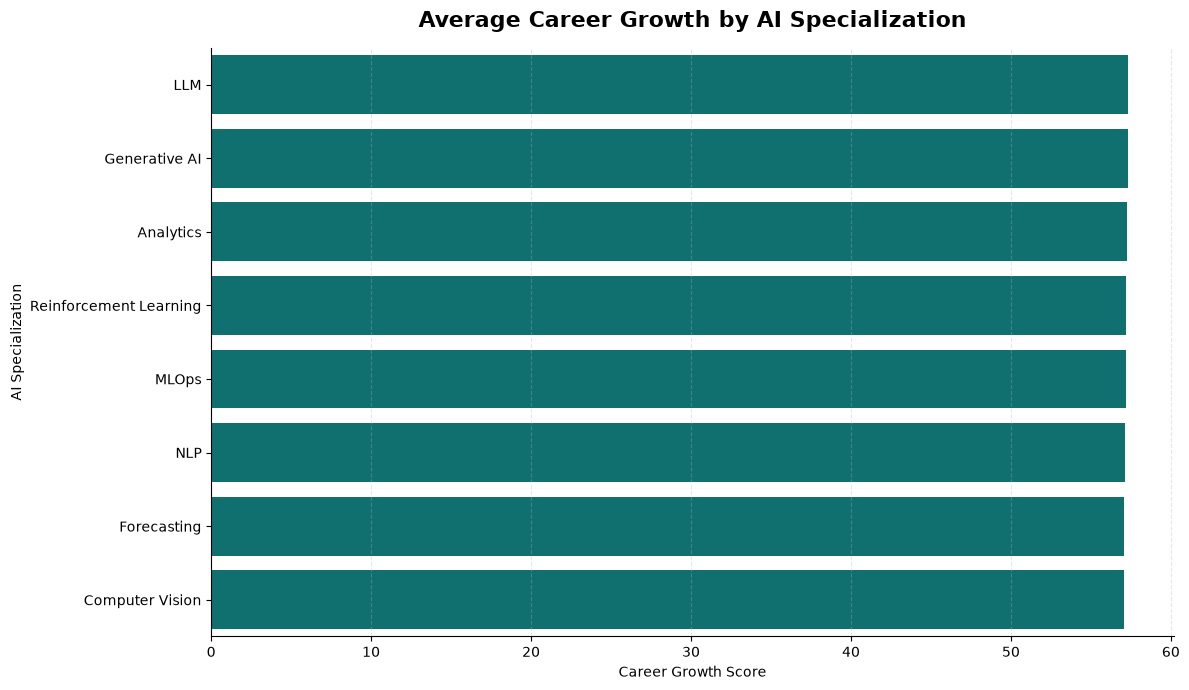

In [18]:
# Chart 6: Career Growth by AI Specialization

career_specialization = (
    df.groupby("ai_specialization")["career_growth_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=career_specialization,
    x="career_growth_score",
    y="ai_specialization",
    color="teal",
    ax=ax
)

ax.set_title(
    "Average Career Growth by AI Specialization",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Career Growth Score")
ax.set_ylabel("AI Specialization")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

## Chart 7: Promotion Speed by Experience Level

**Business Objective:** Visualize **promotion speed by experience level** to support career growth analysis and decision-making.

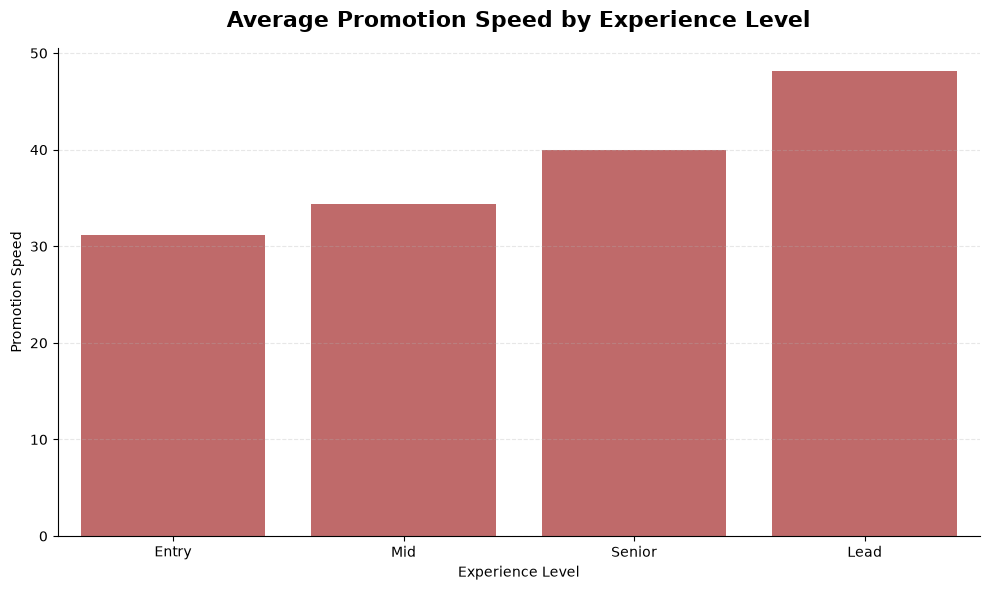

In [19]:
# Chart 7: Promotion Speed by Experience Level

promotion_exp = (
    df.groupby("experience_level", observed=False)["promotion_speed"]
    .mean()
    .reindex(experience_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=promotion_exp,
    x="experience_level",
    y="promotion_speed",
    color="indianred",
    ax=ax
)

ax.set_title(
    "Average Promotion Speed by Experience Level",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Experience Level")
ax.set_ylabel("Promotion Speed")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

## Chart 8: Salary vs Career Growth

**Business Objective:** Visualize **salary vs career growth** to support career growth analysis and decision-making.

In [ ]:
# Chart 8: Salary vs Career Growth

fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="salary_usd",
    y="career_growth_score",
    alpha=0.35,
    s=35,
    ax=ax
)

ax.set_title("Salary vs Career Growth Score", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Career Growth Score")
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 9: Career Growth by Experience Years

**Business Objective:** Visualize **career growth by experience years** to support career growth analysis and decision-making.

In [ ]:
# Chart 9: Career Growth by Experience Years

career_years = (
    df.groupby("experience_years")["career_growth_score"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12,6))

sns.lineplot(
    data=career_years.reset_index(),
    x="experience_years",
    y="career_growth_score",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Career Growth Across Experience Years", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Experience Years")
ax.set_ylabel("Career Growth Score")
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 10: Correlation Heatmap

**Business Objective:** Visualize **correlation heatmap** to support career growth analysis and decision-making.

In [ ]:
# Chart 10: Career Growth Correlation Heatmap

career_corr = (
    df[[
        "career_growth_score",
        "promotion_speed",
        "salary_percentile",
        "experience_years",
        "salary_usd",
        "bonus_usd",
        "skill_demand_score",
        "job_security_score",
        "employee_satisfaction",
        "work_life_balance_score"
    ]]
    .corr()
)

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(
    career_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8},
    ax=ax
)

ax.set_title("Career Growth Correlation Matrix", fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()